In [1]:
# Diffusion modellek importálása
# - StableDiffusionPipeline: text-to-image generálás
# - StableDiffusionImg2ImgPipeline: frame-to-frame módosítás (animációhoz)
from diffusers import StableDiffusionPipeline, StableDiffusionImg2ImgPipeline

# Képfeldolgozás
from PIL import Image

# PyTorch GPU használathoz
import torch

# Fájlrendszer műveletekhez
import os

# Numerikus műveletek (fade-out effekt)
import numpy as np


# Létrehozzuk a frame-ek tárolására szolgáló mappát
os.makedirs("frames", exist_ok=True)

# Meghatározzuk a futtatási eszközt (GPU ajánlott)
device = "cuda"


# -------------------------------
# TEXT-TO-IMAGE PIPELINE
# -------------------------------
# Első képkocka generálása pusztán szöveges promptból
pipe_txt2img = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16  # kisebb memóriahasználat
).to(device)


# -------------------------------
# IMAGE-TO-IMAGE PIPELINE
# -------------------------------
# Következő frame-ek generálása az előző frame módosításával
pipe_img2img = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to(device)


# Memóriaoptimalizálás (fontos Colab GPU esetén)
pipe_txt2img.enable_attention_slicing()
pipe_img2img.enable_attention_slicing()


# Összes generált frame száma
# 225 frame 30 FPS exportnál kb. 15 másodperc,
# duplázással ~30 másodperc hatás
num_frames = 225


# -------------------------------
# PROMPT EVOLÚCIÓ (JELENETSTRUKTÚRA)
# -------------------------------
# A film három szakaszra bontva:
# 1. Távoli jelenet
# 2. Közeledés
# 3. Close-up
def get_prompt(i):
    if i < 75:
        return "cinematic cat walking in dark foggy forest, volumetric light, 35mm film"
    elif i < 150:
        return "cinematic cat approaching camera, dramatic lighting, mist, shallow depth of field"
    else:
        return "extreme close-up of cat face, emotional, dramatic shadows, film grain"


# -------------------------------
# 1. FRAME GENERÁLÁSA (TEXT2IMG)
# -------------------------------

# Az első frame teljesen új generálás
first_prompt = get_prompt(0)

first_frame = pipe_txt2img(
    first_prompt,
    guidance_scale=8  # mennyire kövesse a promptot
).images[0]

# Mentés
first_frame.save("frames/frame_000.png")

# Ezt fogjuk módosítani iteratívan
previous_frame = first_frame


# -------------------------------
# TEMPORÁLIS ANIMÁCIÓ (IMG2IMG)
# -------------------------------

for i in range(1, num_frames):

    # Aktuális jelenethez tartozó prompt
    prompt = get_prompt(i)

    # Kép mérete
    width, height = previous_frame.size

    # ---------------------------------
    # Zoom effekt (kamera közelítés)
    # ---------------------------------
    zoom_factor = 0.992  # minden frame-ben minimális zoom
    new_width = int(width * zoom_factor)
    new_height = int(height * zoom_factor)

    # Középre igazított crop
    left = (width - new_width) // 2
    top = (height - new_height) // 2
    right = left + new_width
    bottom = top + new_height

    # Kivágás
    zoomed = previous_frame.crop((left, top, right, bottom))

    # Visszaméretezés eredeti méretre
    # Ez hozza létre a "kamera közelít" hatást
    zoomed = zoomed.resize((width, height), Image.LANCZOS)


    # ---------------------------------
    # Új frame generálása
    # ---------------------------------
    # strength:
    # 0 → majdnem ugyanaz marad
    # 1 → teljesen új kép
    # 0.22 → enyhe módosítás, stabil animáció
    new_frame = pipe_img2img(
        prompt,
        image=zoomed,
        strength=0.22,
        guidance_scale=8
    ).images[0]


    # ---------------------------------
    # Fade-out effekt az utolsó 30 frame-ben
    # ---------------------------------
    if i > 195:
        # Lineáris sötétítés
        alpha = 1 - ((i - 195) / 30)

        # Pixelértékek csökkentése
        dark = np.array(new_frame) * alpha
        new_frame = Image.fromarray(dark.astype(np.uint8))


    # Frame mentése
    new_frame.save(f"frames/frame_{i:03d}.png")

    # Következő iteráció alapja ez lesz
    previous_frame = new_frame

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

...

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/11 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/11 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


In [2]:
# OpenCV importálása videókezeléshez
import cv2

# Az összes PNG frame fájl összegyűjtése a "frames" mappából
# - csak .png fájlokat veszünk figyelembe
# - sorted() biztosítja a helyes időrendi sorrendet (frame_000, frame_001, ...)
frames = sorted([
    f"frames/{f}"
    for f in os.listdir("frames")
    if f.endswith(".png")
])

# Az első frame betöltése a videó paramétereinek meghatározásához
frame_example = cv2.imread(frames[0])

# A kép méretének lekérdezése
# shape formátum: (magasság, szélesség, színcsatornák)
height, width, _ = frame_example.shape


# ---------------------------------------
# Videóíró objektum létrehozása
# ---------------------------------------

video = cv2.VideoWriter(
    "ai_short_film.mp4",                 # Kimeneti fájlnév
    cv2.VideoWriter_fourcc(*'mp4v'),     # Codec (MP4 formátum)
    30,                                  # FPS (képkocka/másodperc)
    (width, height)                      # Videó felbontása
)

# ---------------------------------------
# Frame-ek hozzáadása a videóhoz
# ---------------------------------------

for f in frames:

    # Aktuális frame betöltése
    img = cv2.imread(f)

    # Frame hozzáadása a videóhoz
    video.write(img)

    # Ugyanaz a frame még egyszer hozzáadva
    # Ez mesterségesen növeli az időtartamot és simább mozgást ad
    # (kvázi frame-duplikációs interpoláció)
    video.write(img)

# ---------------------------------------
# Videófájl lezárása és mentése
# ---------------------------------------

video.release()

In [3]:
# Importáljuk a BLIP modellt és processor-t
from transformers import BlipProcessor, BlipForConditionalGeneration

# Képfeldolgozás
from PIL import Image

# Adatkezelés / táblázat
import pandas as pd


# -------------------------------
# BLIP processor és modell betöltése
# -------------------------------
# BLIP: Bootstrapped Language-Image Pretraining
# Képekből automatikus leírásokat generál
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")


# -------------------------------
# FRAME-LEVEL CAPTION GENERÁLÁS
# -------------------------------
captions = []  # ide gyűjtjük a generált captionöket

for f in frames:
    # Frame betöltése és RGB konverzió
    img = Image.open(f).convert("RGB")

    # Kép feldolgozása a BLIP modell inputjához
    inputs = processor(img, return_tensors="pt")

    # Caption generálása
    out = blip_model.generate(**inputs)

    # Tokenek dekódolása emberi olvasható szöveggé
    caption = processor.decode(out[0], skip_special_tokens=True)

    # Hozzáadás a listához
    captions.append(caption)


# -------------------------------
# TÁBLÁZATBA RENDEZÉS
# -------------------------------
df = pd.DataFrame({
    "frame": list(range(len(captions))),  # frame index
    "caption": captions                   # generált leírás
})

# Első néhány sor megtekintése
df.head()

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

,frame,caption
0,0,a cat walking down a path in a forest
1,1,a cat walking down a path in the woods
2,2,a cat walking down a path in the woods
3,3,a cat walking down a path in the woods
4,4,a cat walking down a path in the woods


In [4]:
# -------------------------------
# Szógyakoriság elemzés
# -------------------------------

from collections import Counter  # a Counter segítségével könnyen számolhatjuk a szavak előfordulását

all_words = []  # ide gyűjtjük az összes szó összes caption-ből

for cap in captions:
    # A caption kisbetűsítése a normalizálás érdekében
    # majd szóközök mentén való szétbontás (split) a külön szavakhoz
    all_words += cap.lower().split()

# Counter objektum létrehozása
# - kulcs: szó
# - érték: előfordulások száma
word_counts = Counter(all_words)

# A 20 leggyakoribb szó kiíratása, a leggyakoribbtól a kevésbé gyakori felé
print(word_counts.most_common(20))

[('a', 450), ('cat', 130), ('the', 99), ('of', 97), ('with', 88), ('walking', 83), ('in', 80), ('is', 69), ('forest', 63), ('red', 62), ('through', 61), ('and', 60), ('background', 57), ('black', 53), ('white', 53), ('flower', 53), ('colorful', 44), ('sitting', 41), ('tunnel', 37), ('path', 25)]


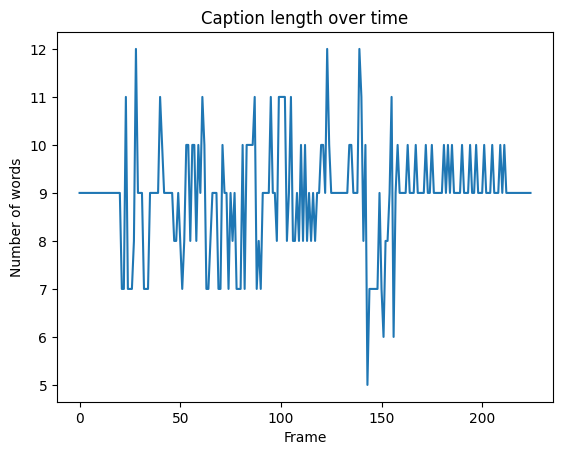

In [5]:
# -------------------------------
# Caption hosszának elemzése és vizualizálása
# -------------------------------

import matplotlib.pyplot as plt  # grafikonokhoz


# Lista létrehozása, ahol minden elem a caption szavainak száma
lengths = [len(cap.split()) for cap in captions]


# -------------------------------
# Grafikon létrehozása
# -------------------------------
plt.plot(lengths)               # caption hossz időben (frame index szerint)
plt.title("Caption length over time")  # grafikon címe
plt.xlabel("Frame")             # x-tengely: frame index
plt.ylabel("Number of words")   # y-tengely: szavak száma a caption-ben
plt.show()                      # megjelenítés